<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/MSOC_banner.png' align='right' width='100%'/>

<a href="../Index.ipynb">Index</a> | <a href="./Access_OLCI_EUMETSAT_Data_Store.ipynb">Accessing Sentinel-3 OLCI data through the EUMETSAT Data Store</a> | <a href="./Access_PACE_EarthData.ipynb">Accessing PACE OCI through EarthData</a> | <a href="./Access_MSI_CDSE.ipynb">Accessing Sentinel-2 MSI data via the CDSE</a> 

**Copyright:** 2025 MSOC training team <br>
**License:** MIT <br>
**Authors:** Ben Loveday (Innoflair for EUMETSAT), Ana Ruescas (Brockmann Consult / University of Valencia), Anna Windle diPaolo (NASA)

<div class="alert alert-block alert-success">
<h3>Multi-sensor Ocean Colour Course</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
This notebook has the following prerequisites:
- You should have built and activated the appropriate `msoc` Python environment in either your command line, or in the Anaconda navigator prior to launching this notebook.

Optional:

- **<a href="https://identity.dataspace.copernicus.eu/auth/realms/CDSE/login-actions/registration?client_id=account-console&tab_id=7mxjCv4mJxw" target="_blank">A Copernicus Data Space Ecosystem account</a>** if you want to download new Sentinel-2 MSI data from the CDSE.
- **<a href="https://user.eumetsat.int/register" target="_blank">A EUMETSAT User Portal account</a>** if you want to download new Sentinel-3 OLCI marine data from the EUMETSAT Data Store
- **<a href="https://my.wekeo.eu/user-registration" target="_blank">A WEkEO account</a>** if you want to download new Sentinel-2 MSI or Sentinel-3 OLCI marine data from WEkEO.
- **<a href="https://urs.earthdata.nasa.gov/" target="_blank">An Earthdata account</a>** if you want to download new PACE OCI data from Earthdata.

There are no prerequisite notebooks for this module.
</div>
<hr>

# Comparing atmospheric correction methods

### Data used

| Dataset | EUMETSAT collection ID | EUMETSAT collection<br>description | CDSE collection ID | CDSE collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|:-----------------:|:-----------------:|
| Sentinel-3 OLCI level 2 full resolution (operational) | EO:EUM:DAT:0407 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_2_WFR___NTC" target="_blank">Description</a> | - | - | EO:EUM:DAT:SENTINEL-3:OL_2_WFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_2_WFR___" target="_blank">Description</a> |
| Sentinel-3 OLCI level 1b full resolution (operational) | EO:EUM:DAT:0409 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_1_EFR___NTC" target="_blank">Description</a> | - | - |EO:EUM:DAT:SENTINEL-3:OL_1_EFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_1_EFR___" target="_blank">Description</a> |
| Sentinel-2 Level 1C Top of Atmosphere | - | - | sentinel-2-l1c | <a href="https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html#sentinel-2-level-1c-top-of-atmosphere-toa" target="_blank">Description</a> | EO:ESA:DAT:SENTINEL-2 | <a href="https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:ESA:DAT:SENTINEL-2" target="_blank">Description</a> |
| Sentinel-2 Level 2A Surface Reflectance | - | - | sentinel-2-level-2a-surface-reflectance | <a href="https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html#sentinel-2-level-2a-surface-reflectance" target="_blank">Description</a> | EO:ESA:DAT:SENTINEL-2 | <a href="https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:ESA:DAT:SENTINEL-2" target="_blank">Description</a> |

### Learning outcomes

At the end of this notebook you will;
* be familiar with the output of various atmospheric correction (AC) methods for Sentinel-3 OLCI and Sentinel-2 MSI
* understand how these methods perform in different in a comparative scenario

### Outline

Atmospheric correction is a crucial step in ocean-colour remote sensing because the signal measured at the top of the atmosphere is dominated—often 80–95%—by atmospheric contributions from Rayleigh scattering, aerosols, and surface glint. The goal of atmospheric correction is to retrieve the very small water-leaving radiance that carries information about phytoplankton, coloured dissolved organic matter, and suspended particles (figure 1). This process involves modelling and removing the atmospheric path radiance, accounting for gas absorption (notably by ozone and water vapour), and correcting for the bidirectional effects of illumination and observation geometry.

<br><figure style="text-align: center;">
    <img src="https://www.oceanopticsbook.info/packages/iws_l2h/conversion/files/CM_AtmosCorr_Lu_schematic.png" style="width:30%;">
    <figcaption style="font-style: italic; font-size: 0.9em;">
        <br>Figure 1. Contributions to the total upwelling radiance above the sea surface, courtesy of the <a href="https://www.oceanopticsbook.info/" target="_blank">Ocean Optics Web-book</a>.
    </figcaption>
</figure>

In this notebook, we focus on atmospheric correction considerations for Sentinel-3 OLCI and Sentinel-2 MSI, two widely used Copernicus missions for coastal and ocean-colour applications. OLCI provides dedicated ocean-colour spectral bands, including multiple narrow bands in the blue and red regions, enabling more robust aerosol modelling and retrieval of water-leaving reflectance. MSI, although originally designed for land applications, offers high spatial resolution that is particularly valuable in optically complex coastal waters, requiring tailored atmospheric correction approaches due to its wider spectral bands and limited NIR/SWIR coverage. Together, these sensors provide complementary capabilities, and understanding their differences is essential for designing effective atmospheric correction workflows. Here, we will consider multiple approaches, some of which are sensor specific, and some of which can cater for both sensors.

*Note: all the tools used to create the various output products for this notebook are available in the **<a href="../ac_methods" target="_blank">ac_methods</a>** directory of this repository, should you wish to investigate. To run the full suite of algorithms, you will require SNAP with various plugins installed.*

<div class="alert alert-warning" role="alert">

When using this notebook:
* DO NOT just click the cells, get the output and move on.
* Read the cell first and try to understand what it is doing before you run it.
* You will be editing and updating copies of these cells later for your own independent work so make sure you understand them with the worked example before moving on.

</div>

<hr>

<div class="alert alert-info" role="alert">

## Importing dependencies

</div>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [1]:
import os                           # a library that allows us access to basic operating system commands like making directories
import pandas as pd                 # a library that support data analysis
import numpy as np                  # a library that provides support for array-based mathematics
import glob                         # a library that helps us find files
import xarray as xr                 # a library that supports the use of multi-dimensional arrays in Python
import matplotlib.pyplot as plt     # a library that support plotting
import re                           # a library that supports pattern matching
import json                         # a library that provides support in reading JSON format objects
import dask                         # a library for parallel computing on large datasets efficiently
import warnings                     # a library that helps us manage warnings
import eumartools                   # a EUMETSAT library that support working with Copernicus Sentinel products
from pyproj import CRS, Transformer # library that helps us project data

We will also set a few parameters to making running this notebook more convenient.

In [2]:
# suppress warnings
warnings.filterwarnings('ignore')

# memory management
dask.config.set({"array.slicing.split_large_chunks": True})
chunks={"rows": 512, "columns": 512}

<div class="alert alert-warning" role="alert">

## Defining functions

</div>

Next we will define a two quick functions for re-use below. The first function will be used to calculate flag masks from supplied flag names and masks. It will work work for all the Sentinel-2 and Sentinel-3 products we will be working with. The second will calculate latitude and longitude variables for sen2water products. We have hidden these cells by default.

In [3]:
def flag_data(flags, flag_names, flag_values, my_flag_values, flag_bytes=True, dtype=None):
    """
    Return a mask indicating where selected flags are set.

    Parameters
    ----------
    flags : array-like
        Array of per-pixel flag values.
    flag_names : list of str
        Names of all available flags, aligned with `flag_values`.
    flag_values : array-like
        Numeric values for each flag (bitmasks or integer codes).
    my_flag_values : list of str
        Names of the flags to check for.
    flag_bytes : bool, optional
        If True, treat flags as bitwise masks; if False, match values directly.
    dtype : data-type, optional
        Optional dtype for the internal mask array.

    Returns
    -------
    ndarray
        Boolean mask if `flag_bytes=True`, otherwise an array of 0/1 values.
    """
    if not dtype:
        flag_bits = np.zeros(np.shape(flags), np.dtype(type(flags[0][0])))
    else:
        flag_bits = np.zeros(np.shape(flags), dtype)

    for flag in my_flag_values:
        if flag_bytes:
            try:
                flag_bits = flag_bits | flag_values[flag_names.index(flag)]
            except:
                print(flag + " not present")
        else:
            flag_bits[flags==flag_values[flag_names.index(flag)]] = 1

    if flag_bytes:
        return (flags & flag_bits) > 0
    else:
        return flag_bits

In [4]:
def xy_to_latlon_grid(x, y, crs_from="EPSG:3857", crs_to="EPSG:4326"):
    """
    Construct 2D latitude/longitude grids from 1D x and y coordinates and a CRS.

    Parameters
    ----------
    x : 1D array-like
        X coordinates (e.g., easting).
    y : 1D array-like
        Y coordinates (e.g., northing).
    crs_from : str or CRS
        Input coordinate reference system.
    crs_to : str or CRS
        Output CRS (default = WGS84 lat/lon).

    Returns
    -------
    lats : 2D array
        Latitude grid.
    lons : 2D array
        Longitude grid.
    """
    # Create projection transformer
    transformer = Transformer.from_crs(CRS.from_user_input(crs_from),
                                      CRS.from_user_input(crs_to),
                                      always_xy=True)

    # Create 2D meshgrid in the input CRS
    X, Y = np.meshgrid(x, y)

    # Transform to lat/lon
    lons, lats = transformer.transform(X, Y)
    return lats, lons

<div class="alert alert-info" role="alert">

## Setting up the experiment

</div>

Lets now set-up our experiment, starting with pointing the notebook to our pre-prepared data directory. This cell will check if the data directory you specify exists. You can adapt this path to point at your own data.

In [5]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), "Data", "Preprepared", "Day2", "Atmospheric_correction", "L2_processed")
print(f"Data directory is: {data_dir}")
if not os.path.exists(data_dir):
    print("Please check you have put the example data in the correct place, or adapt the path above to your ROI or data")
else:
    print("Found data directory!")

Data directory is: /Users/benloveday/Code/git_repositories/msoc/Data/Preprepared/Day2/Atmospheric_correction/L2_processed
Found data directory!


Next, we will define the sensor we are using and a single wavelength to focus the first part of the analyis on. The code will choose the nearest Sentinel-3 OLCI or Sentinel-2 MSI band to this wavelength, but **no interpolation or band-shifting will be performed**. To avoid any ambiguity, we recommend you choose a value that is either exactly, or very close to, a band that is present in the native bandset of the relevant sensor. We'll also set a couple of grid parameters to control memory use and plot extent.

In [6]:
# set the sensor we want to work with (S2 or S3)
sensor = "S3"

# set the "target band" wavelength for the analysis; the nearest native band to this value will be used
target_band = {"S2": 560, "S3": 560}

# set a subsampling parameter to reduce memory load; you are free to adapt this to your system
subsampling = {"S2": 5, "S3": 5}

# set a parameter to control plotting so that we can focus on a certain area if needed (W,E,S,N). This does not affect data analysis
plot_box = {"S2": None, "S3": [7.5, 20, 40,46]}

This repository includes some example AERONET_OC data from the AAOT tower, which we will compare against our remote sensing products. The data used is at quality level 1.5 and is processed to Rrs using the ThoMaS software package. For more information on this data set, please contact the principle investigators. Please see the Venice_OCDB_sanitised.csv file for further information.

If you wish to use this data, make sure the switch below is set to true. If you are adapting this notebook for your own location, you should set this to false and adapt the `target_lon` and `target_lat` variables for your own needs.

In [7]:
use_validation_data = True
target_lon = 0
target_lat = 0

# read validation data if required
if use_validation_data:
    csv_path = "Venice_OCDB_sanitised.csv"
    AAOT_data = pd.read_csv(csv_path, skiprows=24, header=1)
    validation_lon = np.nanmean([float(i) for i in AAOT_data["lon"][2:]])
    validation_lat = np.nanmean([float(i) for i in AAOT_data["lat"][2:]])
else:
    validation_lon = target_lon
    validation_lat = target_lat

To set up the final part of the experiment, we are going to define a series of dictionaries that set the parameters for the various file structures of the atmospherically corrected products. These are, in general, consistent between sensor, but are very different across the products, thus the need for a dictionary for each! We will set the parameters for:

* polymer (S2/S3)
* acolite (S2/S3)
* c2rcc (S2/S3)
* sen2cor (S2)
* bac (S3)
* sen2water (S2)

These parameters include:

* `ac`; the name of the AC approach (for reference)
* `file_tag`; the tag for the directory/file(s) to find
* `subfile`; any subfile that need to specifically find if `file_tag` is a directory
* `lon`/`lat`; the longitude and latitude variable names
* `var`; the type of variable we are looking for (e.g. Rw, Rrs, rrs, B, reflectance), referring to the names of the spectral variables themselves
* `conversion`; any conversion that needs to be applied to `var` to "convert" it to Rrs (approximately!)
* `flag_var`; the flag variable name
* `flags`; the flags we want to either include or exclude (using mask_invert below, ni the case of sen2cor)
* `lambda`; only for polymer, to point toward the wavelengths of each band

You will not need to adapt these for the default case, and hopefully they will hold for your own purposes (...but you never know!)
   
All of these products have been processed using the resources and workflows specified in the **<a href="../ac_methods" target="_blank">ac_methods</a>** directory of this repository.

In [8]:
polymer_opts = {"ac": "polymer", "file_tag": "polymer.nc", "subfile": None, "lon": "longitude", "lat": "latitude",
                "var": "Rw", "conversion": 1/np.pi, "flag_var": ["bitmask"],
                "flags": ["LAND", "CLOUD_BASE", "L1_INVALID", "OUT_OF_BOUNDS", "EXCEPTION"],
                "lambda": "bands_rw"}

In [9]:
acolite_opts = {"ac": "acolite", "file_tag": "acolite", "subfile": "L2W", "lon": "lon", "lat": "lat",
                "var": "Rrs", "conversion": None, "flag_var": ["l2_flags"],
                "flags": ["flag_exponent_swir", "flag_exponent_cirrus", "flag_exponent_toa", "flag_exponent_negative", "flag_exponent_outofscene", "flag_exponent_mixed"]}

In [10]:
c2rcc_opts = {"ac": "c2rcc", "file_tag": "c2rcc.nc", "subfile": None, "lon": "lon", "lat": "lat",
              "var": "rrs", "conversion": None, "flag_var": ["pixel_classif_flags"],
              "flags" : ["IDEPIX_INVALID", "IDEPIX_CLOUD", "IDEPIX_CLOUD_AMBIGUOUS", "IDEPIX_CLOUD_SURE", "IDEPIX_CLOUD_BUFFER", "IDEPIX_CLOUD_SHADOW",
                         "IDEPIX_BRIGHT", "IDEPIX_WHITE", "IDEPIX_COASTLINE", "IDEPIX_LAND"]}

In [11]:
sen2cor_opts = {"ac": "sen2cor", "file_tag": "sen2cor.nc", "subfile": None, "lon": "lon", "lat": "lat",
                "var": "B", "conversion": 1/np.pi, "flag_var": ["quality_scene_classification"],
                "flags" : ["WATER"]}

In [12]:
bac_opts = {"ac": "bac", "file_tag": "bac.nc", "subfile": None, "lon": "lon", "lat": "lat",
            "var": "reflectance", "conversion": 1/np.pi, "flag_var": ["WQSF_lsb"],
            "flags" : ["CLOUD", "CLOUD_AMBIGUOUS", "CLOUD_MARGIN", "INVALID", "COSMETIC", "SATURATED", 
                       "SUSPECT", "HISOLZEN", "HIGHGLINT", "SNOW_ICE", "LAND", "AC_FAIL", "WHITECAPS",
                       "ADJAC", "RWNEG_O2", "RWNEG_O3", "RWNEG_O4", "RWNEG_O5", "RWNEG_O6", "RWNEG_O7",
                       "RWNEG_O8"]}

In [13]:
sen2water_opts = {"ac": "sen2water", "file_tag": "sen2water.nc", "subfile": None, "lon": "longitude", "lat": "latitude",
                  "var": "Rw", "conversion": 1/np.pi, "flag_var": ["pixel_classif_flags"],
                  "flags" : ["IDEPIX_INVALID", "IDEPIX_CLOUD", "IDEPIX_CLOUD_AMBIGUOUS", "IDEPIX_CLOUD_SURE", "IDEPIX_CLOUD_BUFFER",
                             "IDEPIX_CLOUD_SHADOW", "IDEPIX_BRIGHT", "IDEPIX_WHITE", "IDEPIX_COASTLINE", "IDEPIX_LAND"]}

lastly, we can select the options we want to implement by adding/removing the relevant options to/from the list below.

*Note: this script is set up to compare 4 approaches, if you wish to use another one, then we recommend that you remove one first!)*

In [14]:
# note sen2cor is removed from this list for now, but you can substitute it in!
all_opts = {"S2": [polymer_opts, acolite_opts, c2rcc_opts, sen2water_opts],
            "S3": [polymer_opts, acolite_opts, c2rcc_opts, bac_opts]}

After all that, we are ready to go....

<div class="alert alert-info" role="alert">

## Loading our atmospherically corrected products

</div>

Now that we have set all the required parameters, we can load our data. The cell below will process the files in the `data_dir` directory according to the parameters in the AC-specific dictionaries we defined above. You can adapt the `data_dir` path to suit your needs. If all goes as expected, you should see a list of netCDF files when you run this cell. If you do not, you should check that you have set the `data_dir` path correctly, and that you have the expected files in there.

In [15]:
df = {}
for opts in all_opts[sensor]:
    print(f"---- Collecting: {opts['ac'].ljust(10)}-----")
    product = glob.glob(os.path.join(data_dir, sensor + f"*{opts['file_tag']}"))[0]
    if opts["subfile"]:
        product = glob.glob(os.path.join(product, f"*{opts['subfile']}*"))[0]
    df[opts["ac"]] = xr.open_dataset(product, chunks=chunks)

    # sen2water create lat/lon
    if "sen2water" in product:
        print('Creating lat/lon grids')
        crs = df[opts["ac"]]["crs"].attrs["crs_wkt"]
        lat,lon = xy_to_latlon_grid(df[opts["ac"]]["x"], df[opts["ac"]]["y"], crs)
        df[opts["ac"]]["longitude"] = (("y", "x"), lon)
        df[opts["ac"]]["latitude"] = (("y", "x"), lat)
    print(f"Opened: {product}")

---- Collecting: polymer   -----
Opened: /Users/benloveday/Code/git_repositories/msoc/Data/Preprepared/Day2/Atmospheric_correction/L2_processed/S3B_OL_1_EFR____20250514T091545_20250514T091845_20250515T111751_0179_106_264_2160_MAR_O_NT_004_polymer.nc
---- Collecting: acolite   -----
Opened: /Users/benloveday/Code/git_repositories/msoc/Data/Preprepared/Day2/Atmospheric_correction/L2_processed/S3B_OL_1_EFR____20250514T091545_20250514T091845_20250515T111751_0179_106_264_2160_MAR_O_NT_004_acolite/S3B_OLCI_2025_05_14_09_15_44_FR_L2W.nc
---- Collecting: c2rcc     -----
Opened: /Users/benloveday/Code/git_repositories/msoc/Data/Preprepared/Day2/Atmospheric_correction/L2_processed/S3B_OL_1_EFR____20250514T091545_20250514T091845_20250515T111751_0179_106_264_2160_MAR_O_NT_004_c2rcc.nc
---- Collecting: bac       -----
Opened: /Users/benloveday/Code/git_repositories/msoc/Data/Preprepared/Day2/Atmospheric_correction/L2_processed/S3B_OL_2_WFR____20250514T091545_20250514T091845_20250515T153607_0179_106

<div class="alert alert-info" role="alert">

## Comparing our band sets

</div>

Once we have found out files, we can read them in. The cell below will ingest these files, extract the spectral bands and compile the wavelengths for each bandset.

In [16]:
bandsets = {}
for opts in all_opts[sensor]:
    print(f"---- Reading: {opts['ac'].ljust(10)}-----")
    bandsets[opts["ac"]] = {}
    bandset = []
    wavelength = []
    for variable in df[opts["ac"]].var():
        if opts["var"] in variable and "unc" not in variable:
            try:
                if "polymer" in opts["ac"] or "sen2water" in opts["ac"]:
                    wavelength.append(float(variable.split(opts["var"])[-1]))
                    bandset.append(variable)
                else:
                    wavelength.append(round(float(df[opts["ac"]][variable].wavelength)))
                    bandset.append(variable)
            except:
                pass
    bandsets[opts["ac"]]["bands"] = bandset
    bandsets[opts["ac"]]["wavelengths"] = wavelength
    print(f"---- Read:    {opts['ac'].ljust(10)}-----")

---- Reading: polymer   -----
---- Read:    polymer   -----
---- Reading: acolite   -----
---- Read:    acolite   -----
---- Reading: c2rcc     -----
---- Read:    c2rcc     -----
---- Reading: bac       -----
---- Read:    bac       -----


Lets check the bands for each product...

In [17]:
headers = ' '.join([i.ljust(30) for i in bandsets])
print(headers)
max_bands = max([len(bandsets[i]["wavelengths"]) for i in bandsets])
for ii in range(max_bands):
    row = []
    for bb in bandsets:
        try:
            row.append(f"{(bandsets[bb]['wavelengths'][ii])}: {(bandsets[bb]['bands'][ii])}".ljust(30))
        except:
            row.append('NaN'.ljust(30))
    print(' '.join(row))

polymer                        acolite                        c2rcc                          bac                           
400.0: Rw400                   401: Rrs_401                   400: rrs_1                     400: Oa01_reflectance         
412.0: Rw412                   412: Rrs_412                   412: rrs_2                     412: Oa02_reflectance         
443.0: Rw443                   443: Rrs_443                   442: rrs_3                     442: Oa03_reflectance         
490.0: Rw490                   490: Rrs_490                   490: rrs_4                     490: Oa04_reflectance         
510.0: Rw510                   510: Rrs_510                   510: rrs_5                     510: Oa05_reflectance         
560.0: Rw560                   560: Rrs_560                   560: rrs_6                     560: Oa06_reflectance         
620.0: Rw620                   620: Rrs_620                   620: rrs_7                     620: Oa07_reflectance         
665.0: R

<div class="alert alert-danger" role="alert">

**WAIT! What do you notice about the above?**

* Are the bands consistently processed?
* Are the output products consistent (and how may this related to our specified conversion factors)?
* Are the wavelengths all the same?
* Why may some approaches use/disregard some bands?
</div>

<div class="alert alert-info" role="alert">

## Comparing single product coverage

</div>

Lets plot a band, using the nearest one to our target value (...with slight differences, as you can see above)! There are three important things to note here.

* Firstly, that we are not applying any flags yet. The coverage of each product is determined by the algorithm itself, the "gaps" in the data, where they exist, cannot be recovered.
* Secondly, as we noticed above, different AC approaches provide different output products. These may be remote sensing relfectance (R$_{rs}$), normalised water leaving reflectance (R$_{w}$) or bottom of atmosphere reflectance (e.g. "BX" in the case of sen2cor). The conversion factors we specify aim to convert, at least to some extent, to R$_{rs}$.
* Lastly, the red cross you notice on the map indicates the location of our validation data point (or the location you specified).

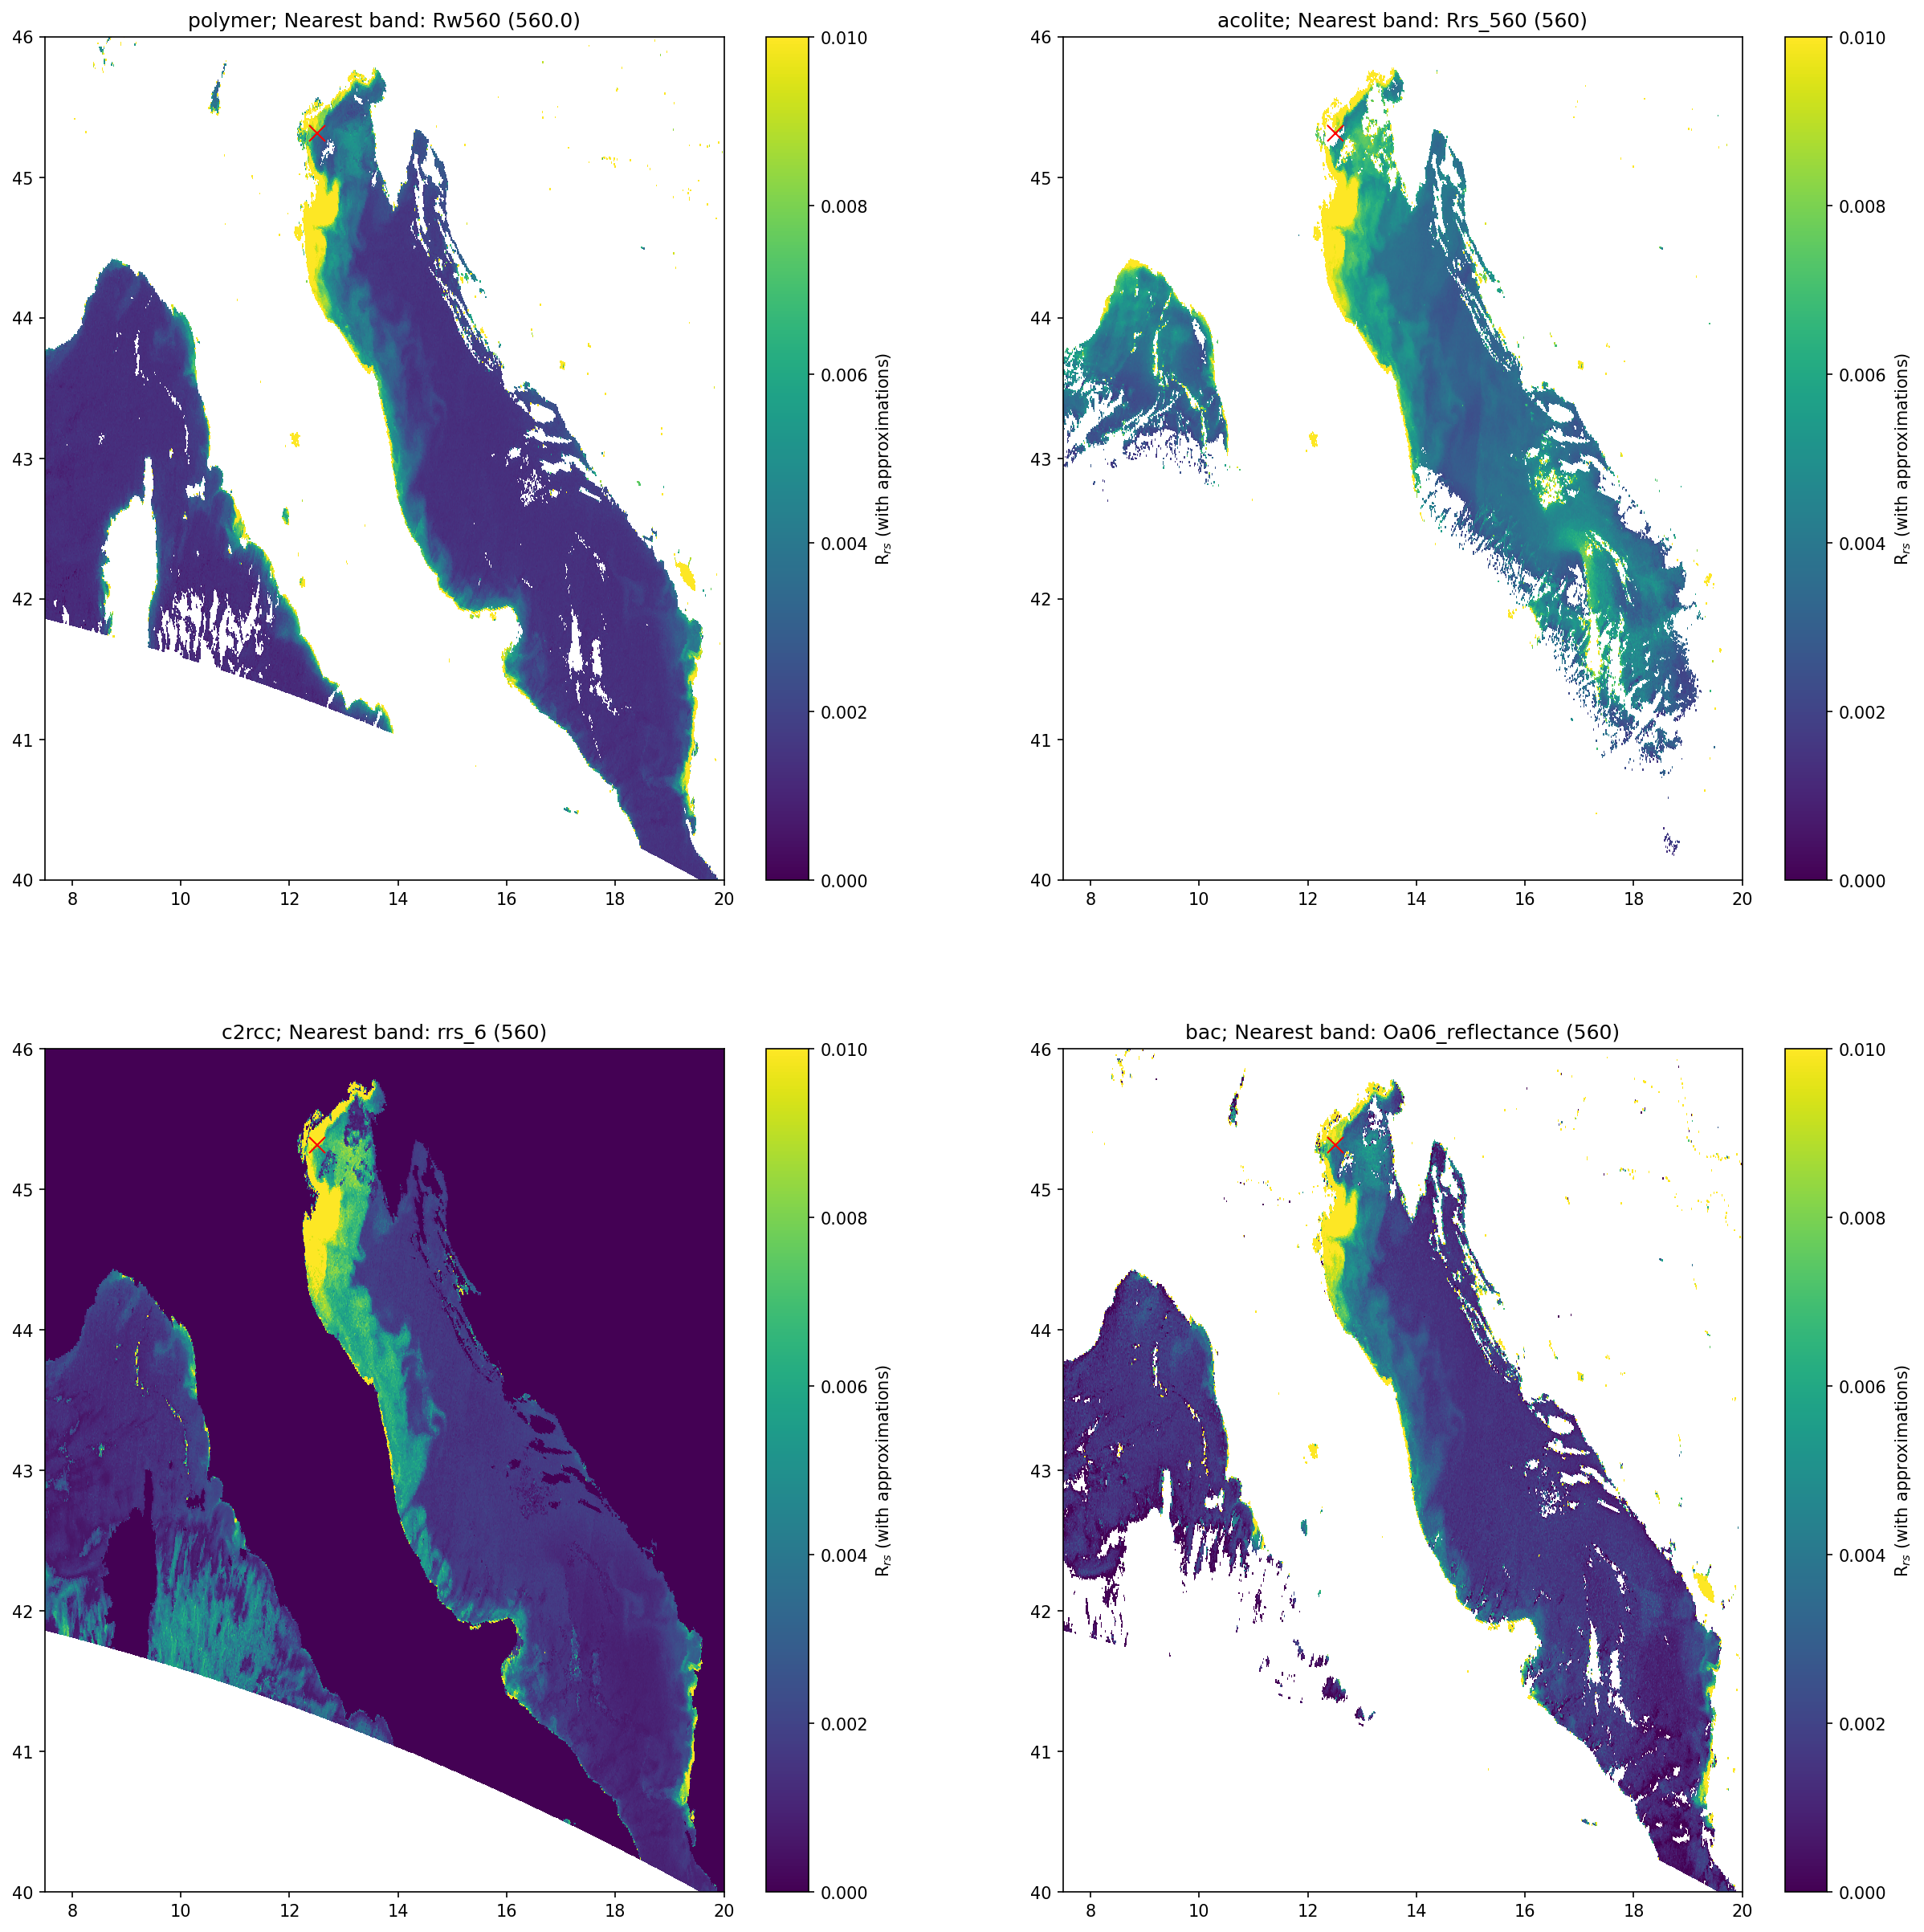

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(20, 20), dpi=150)
plot_bands = {}
for opts, ax in zip(all_opts[sensor], axs.flatten()):
    nearest_band = np.argmin([abs(target_band[sensor] - i) for i in bandsets[opts['ac']]["wavelengths"]])
    nearest_band_name = bandsets[opts['ac']]['bands'][nearest_band]
    plot_bands[opts["ac"]] = df[opts["ac"]][nearest_band_name]
    if opts["conversion"]:
        plot_bands[opts["ac"]] = plot_bands[opts["ac"]] * opts["conversion"]

    p1 = ax.pcolormesh(df[opts["ac"]][opts["lon"]][::subsampling[sensor], ::subsampling[sensor]],
                       df[opts["ac"]][opts["lat"]][::subsampling[sensor], ::subsampling[sensor]],
                       plot_bands[opts["ac"]][::subsampling[sensor], ::subsampling[sensor]],
                       vmin=0, vmax=0.01)

    if plot_box[sensor]:
        ax.set_xlim([plot_box[sensor][0], plot_box[sensor][1]])
        ax.set_ylim([plot_box[sensor][2], plot_box[sensor][3]])
        
    if use_validation_data:
        ax.plot(validation_lon, validation_lat, "rx", markersize=10)

    plt.colorbar(p1, ax=ax, label="R$_{rs}$ (with approximations)")
    ax.set_title(f"{opts['ac']}; Nearest band: {nearest_band_name} ({bandsets[opts['ac']]['wavelengths'][nearest_band]})")

<div class="alert alert-danger" role="alert">

**WAIT! What do you notice about the above?**

* How do the coverages differ? Are there regions where a given AC may provide more information/coverage?
* How can we refine this picture?
* We have done a simple conversion to Rrs, but what factors have we not taken into account?
* What assumptions have we made in our conversions?
</div>

<div class="alert alert-info" role="alert">

## Applying flags

</div>

As you may have noted above, the "raw" data picture gives us some insight into product coverage, but we don't much about the qualituy of the data that has been retained. In order to better assess this, we should consider what flags are available. The cell below will read in the flags that we specified in our parameter dictionaries. (Note that we will explore flags further in the second part of our day 2 practical, where we will use SNAP).

In [19]:
flag_masks = {}
for opts in all_opts[sensor]:
    flag_bytes = True
    mask_invert = False
    print(f"---- Reading: {opts['ac'].ljust(10)}-----")
    for flag in opts["flag_var"]:
        print(f"{flag}")
        flags = df[opts["ac"]][flag].data
        flag_names = []
        flag_values = []
        
        if "c2rcc" in opts['ac'] or "bac" in opts['ac'] or "sen2water" in opts['ac']:
            flag_names = df[opts["ac"]][flag].attrs["flag_meanings"].split(' ')
            flag_values = df[opts["ac"]][flag].attrs["flag_masks"]

        elif "polymer" in opts['ac']:
            for i in df[opts["ac"]][flag].attrs["description"].split(' '):
                flag_names.append(i.split(":")[0])
                flag_values.append(i.split(':')[1].replace(',', ''))

        elif "sen2cor" in opts['ac']:
            flag_names = df[opts["ac"]][flag].attrs["flag_meanings"].split(' ')
            flag_values = df[opts["ac"]][flag].attrs["flag_values"]
            flag_bytes = False
            mask_invert = True
            
        elif "acolite" in opts['ac']:
            for i in df[opts["ac"]].attrs:
                if "flag" in i and not "viirs" in i:
                    flag_names.append(i)
                    flag_values.append(df[opts["ac"]].attrs[i])

        mask = flag_data(np.array(flags, dtype=np.uint64), flag_names, np.array(flag_values, dtype=np.uint64), opts["flags"], flag_bytes=flag_bytes)

        if mask_invert:
            flag_masks[opts["ac"]] = mask - 1
        else:
            flag_masks[opts["ac"]] = mask            

---- Reading: polymer   -----
bitmask
---- Reading: acolite   -----
l2_flags
---- Reading: c2rcc     -----
pixel_classif_flags
---- Reading: bac       -----
WQSF_lsb
RWNEG_O2 not present
RWNEG_O3 not present
RWNEG_O4 not present
RWNEG_O5 not present
RWNEG_O6 not present
RWNEG_O7 not present
RWNEG_O8 not present


Now we have our flags, let plot the flag map to get a better idea of where we have valid data.

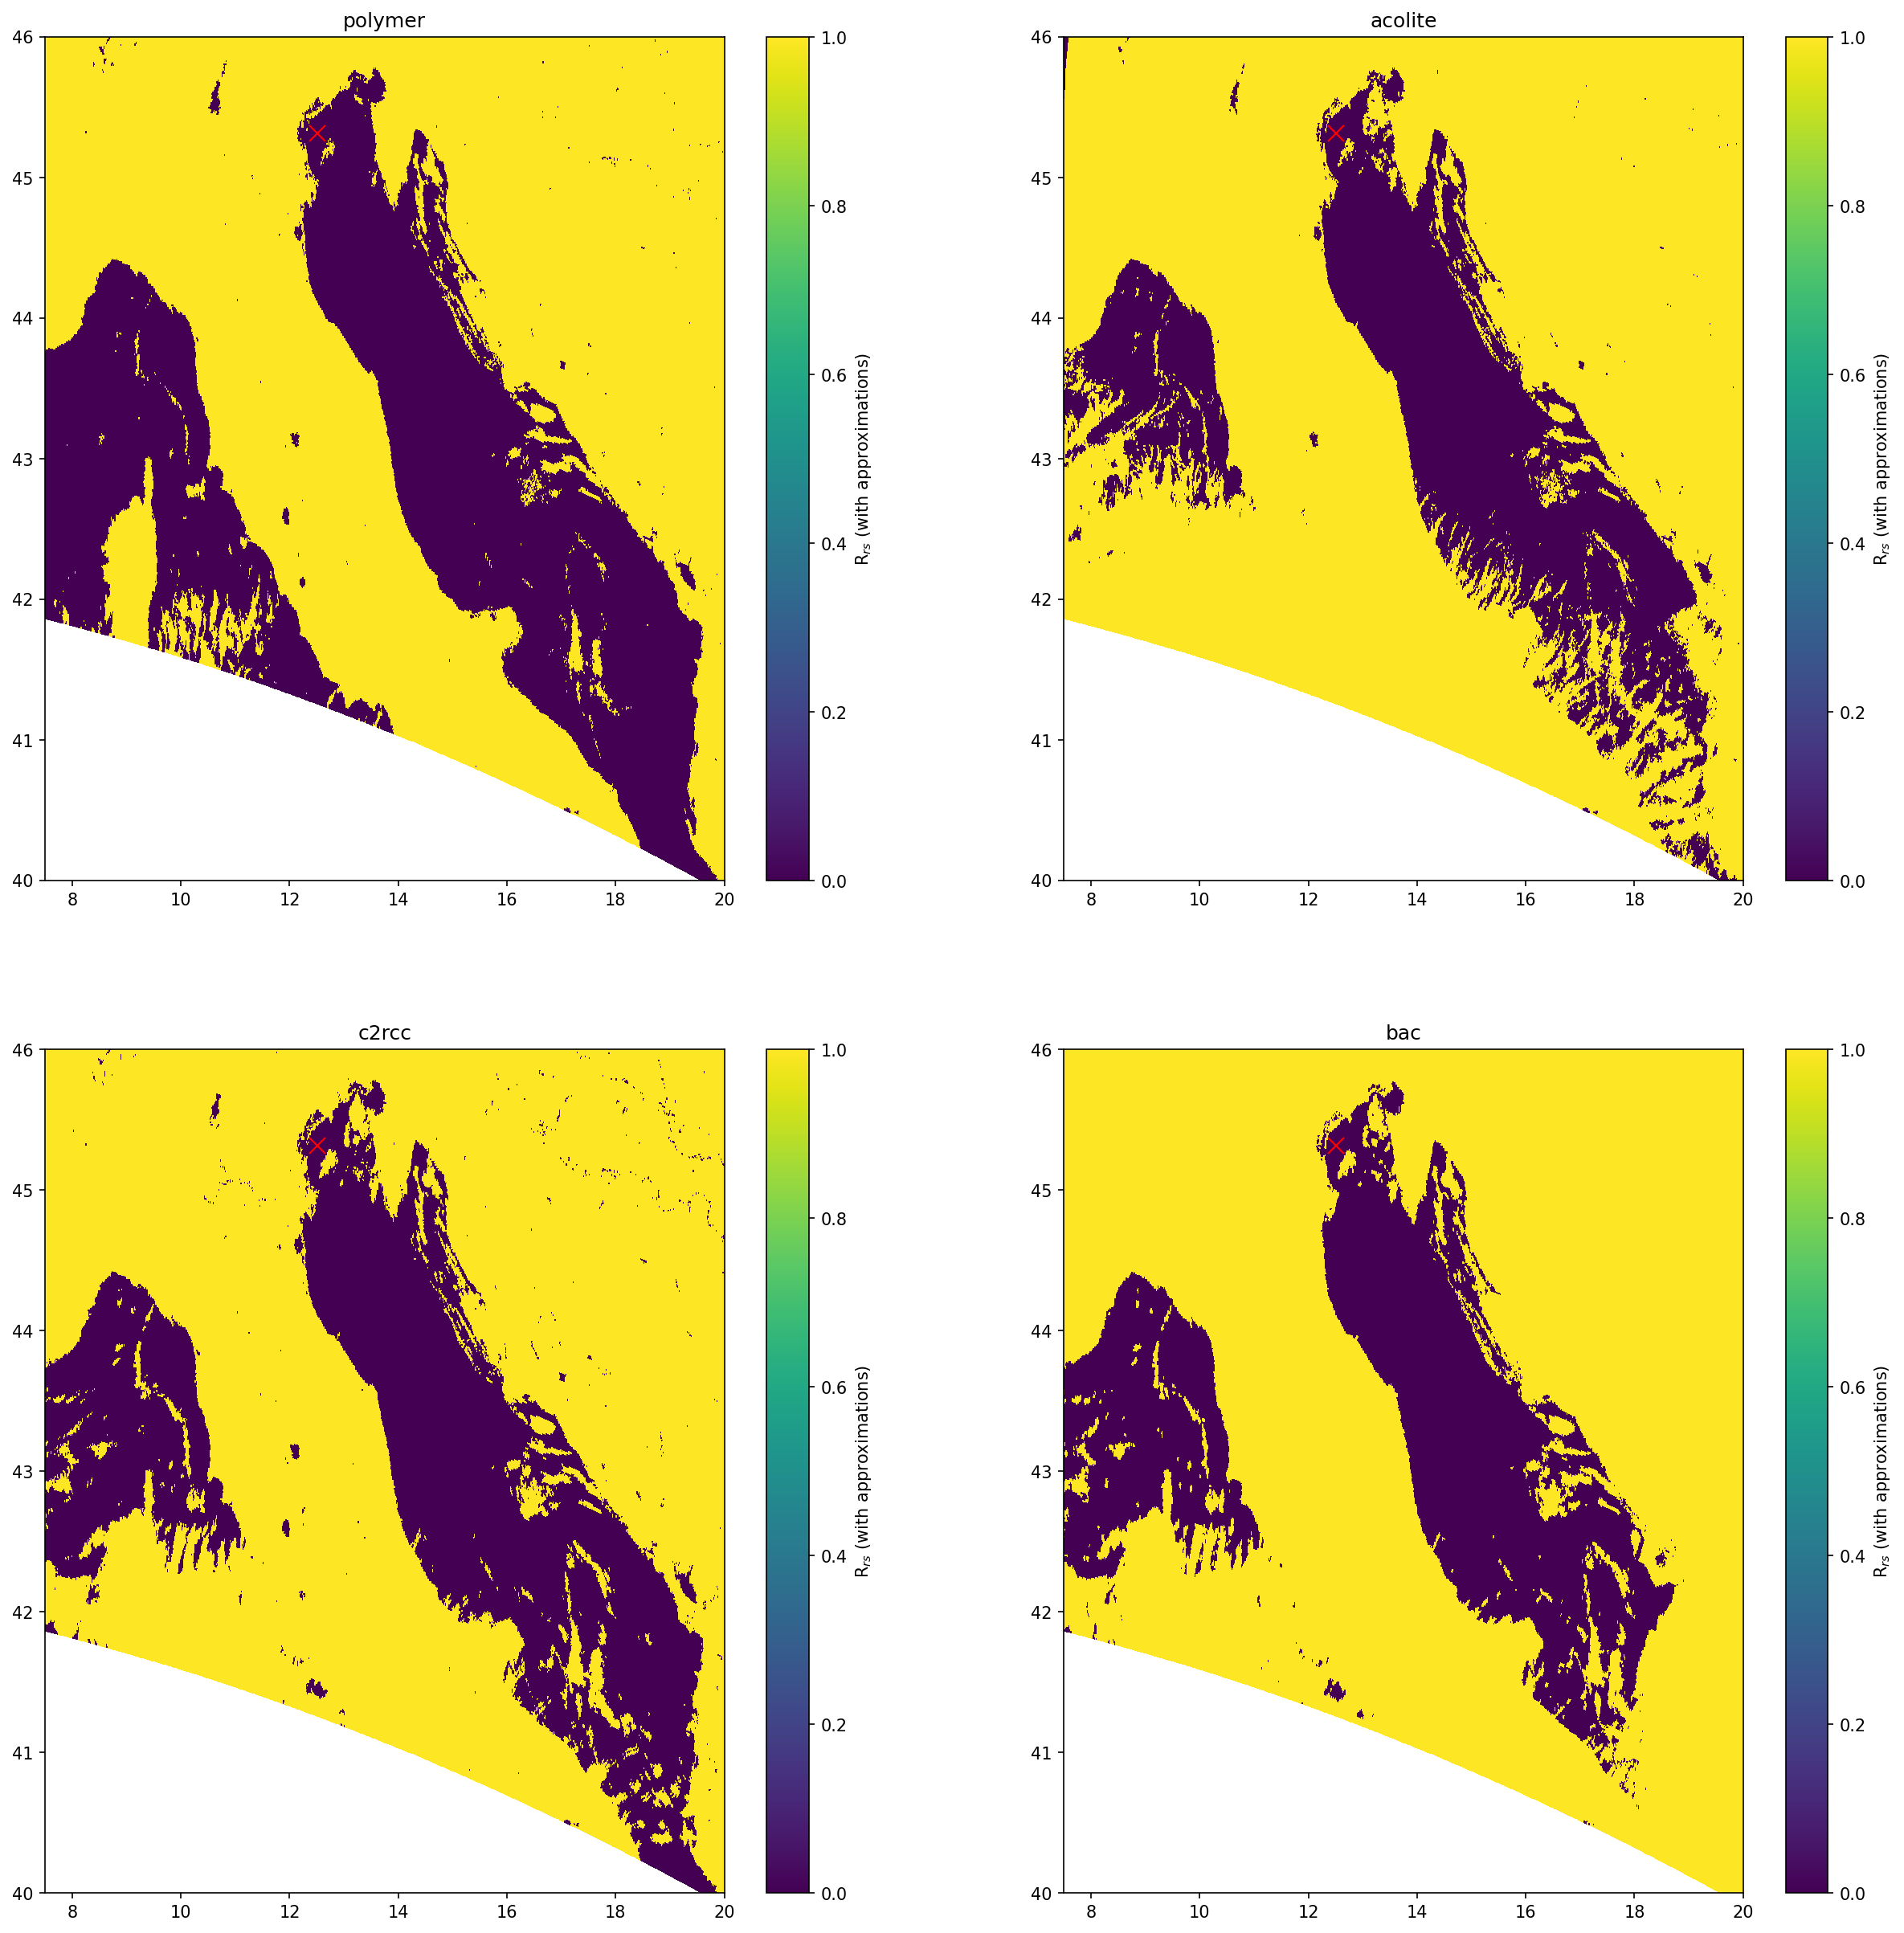

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(20, 20), dpi=150)

for opts, ax in zip(all_opts[sensor], axs.flatten()):

    p1 = ax.pcolormesh(df[opts["ac"]][opts["lon"]][::subsampling[sensor], ::subsampling[sensor]],
                       df[opts["ac"]][opts["lat"]][::subsampling[sensor], ::subsampling[sensor]],
                       flag_masks[opts["ac"]][::subsampling[sensor], ::subsampling[sensor]],
                       vmin=0, vmax=1)

    if plot_box[sensor]:
        ax.set_xlim([plot_box[sensor][0], plot_box[sensor][1]])
        ax.set_ylim([plot_box[sensor][2], plot_box[sensor][3]])
        
    if use_validation_data:
        ax.plot(validation_lon, validation_lat, "rx", markersize=10)

    plt.colorbar(p1, ax=ax, label="R$_{rs}$ (with approximations)")
    ax.set_title(f"{opts['ac']}")

<div class="alert alert-danger" role="alert">

**WAIT! What do you notice about the above?**

* Which approach seems to give the best coverage?
* Can you offer any explanation as to why?
* Do you think you can learn more by adapting the flag recipes above and re-running?
</div>

<div class="alert alert-info" role="alert">

## Making radiometric comparisons

</div>

We have compared the spatial coverage of each approach, but have not yet looked at the individual points to see if there are biases between the data sets. Let's plot all the points for each AC method against all the other points. We will only consider the points that survive our flagging approach and are common to both datasets in each case.

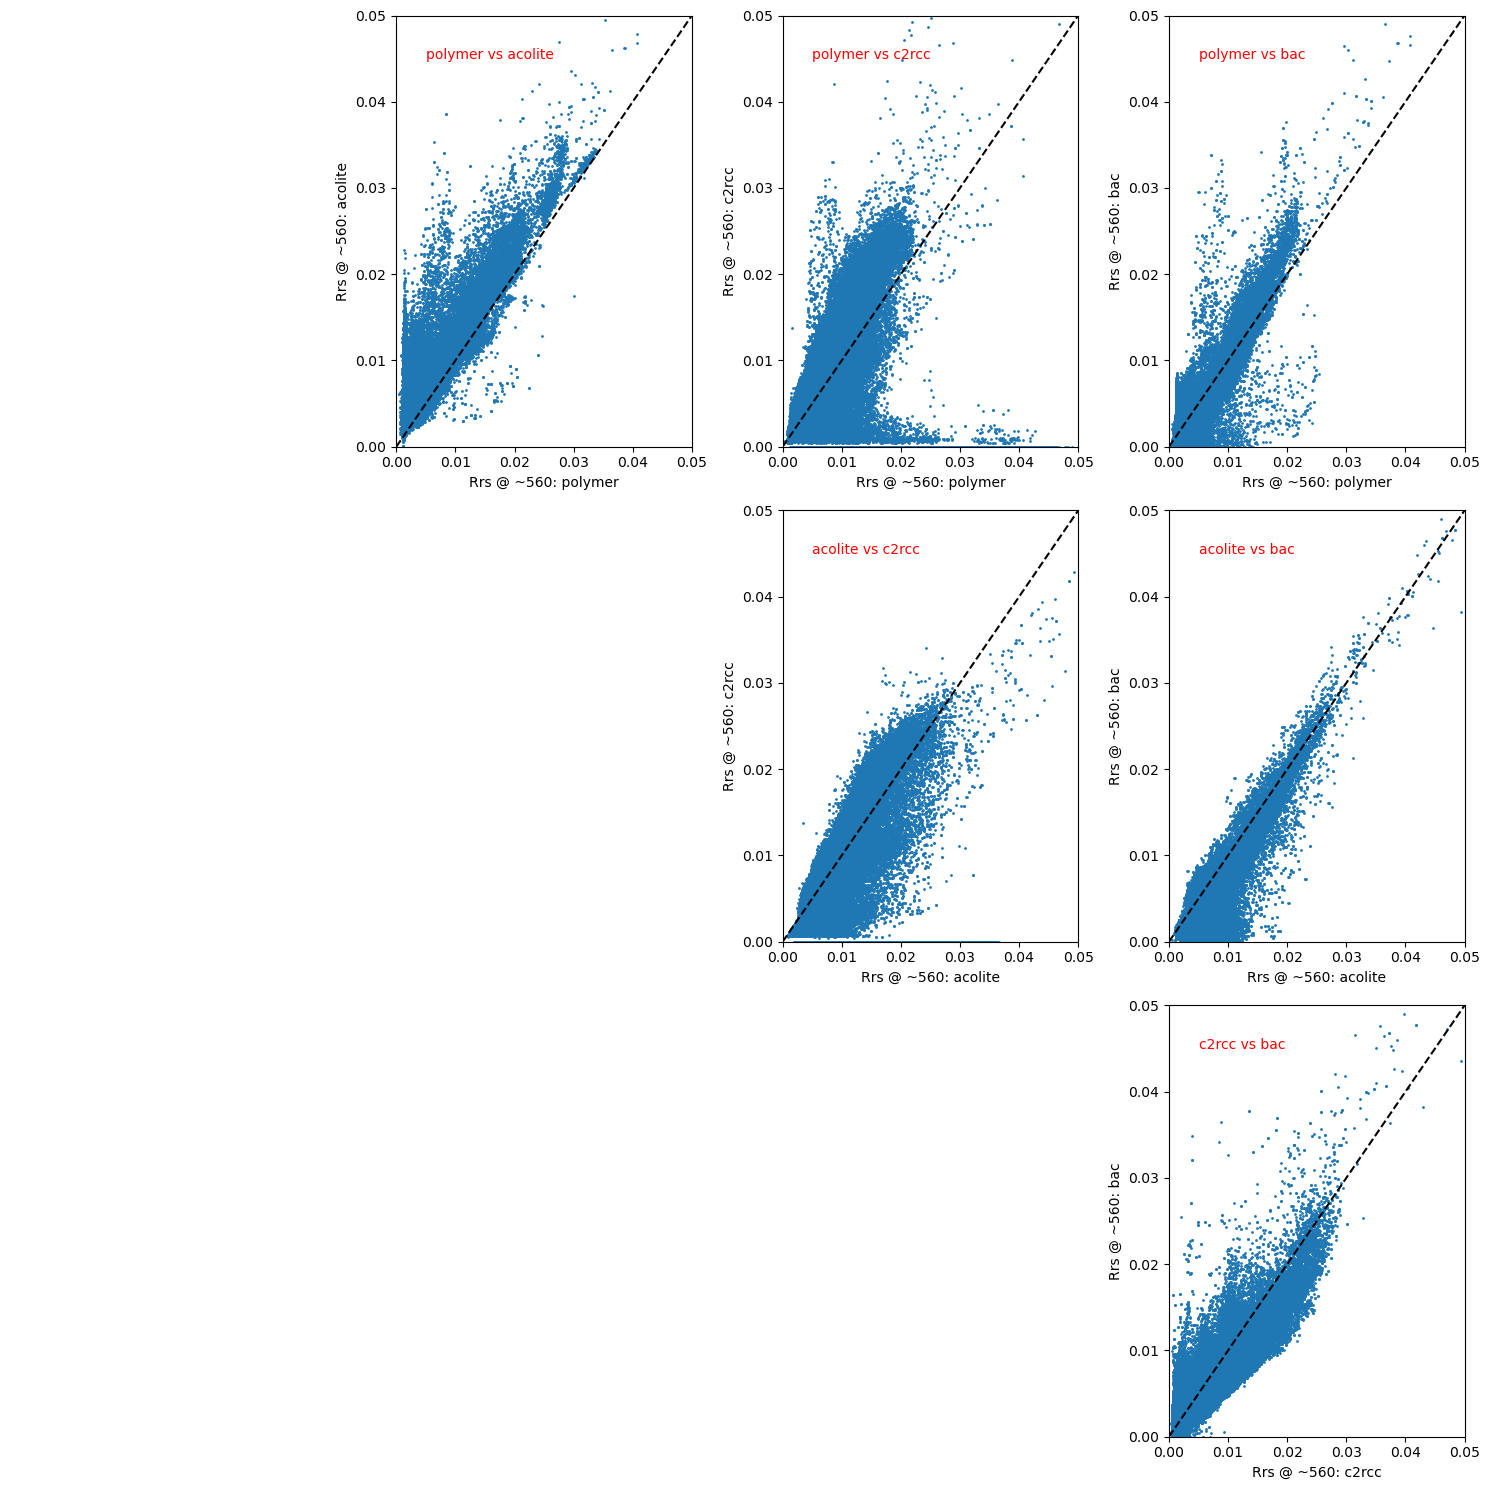

In [21]:
fig, axs = plt.subplots(3, 4, figsize=(15, 15))
minlim = 0.0
maxlim = 0.05
for opts_i, i in zip(all_opts[sensor], range(len(all_opts[sensor]))):
    if i == 3:
        break
    for opts_j, j in zip(all_opts[sensor], range(len(all_opts[sensor]))):
        if i >= j:
            axs[i, j].axis('off')
            continue
        unified_mask = (flag_masks[opts_i["ac"]] + flag_masks[opts_j["ac"]]).astype(float)
        unified_mask[unified_mask != 0.0] = np.nan
        unified_mask[unified_mask == 0.0] = 1.0
        axs[i, j].scatter(plot_bands[opts_i["ac"]] * unified_mask,
                          plot_bands[opts_j["ac"]] * unified_mask, s=1)
        axs[i, j].plot([minlim, maxlim], [minlim, maxlim], "k--")
        axs[i, j].set_xlim([minlim, maxlim])
        axs[i, j].set_ylim([minlim, maxlim])
        axs[i, j].set_xlabel(f"Rrs @ ~{target_band[sensor]}: {opts_i['ac']}")
        axs[i, j].set_ylabel(f"Rrs @ ~{target_band[sensor]}: {opts_j['ac']}")        
        axs[i, j].annotate(f"{opts_i['ac']} vs {opts_j['ac']}", (maxlim*0.1, maxlim*0.9), c='r')

plt.tight_layout()

<div class="alert alert-danger" role="alert">

**WAIT! What do you notice about the above?**

* How do the approaches compare?
* Are there any clear methodological outliers?
* How does this pattern change for different target bands?
* How does this pattern compare if you change the flags applied?
</div>

<div class="alert alert-info" role="alert">

## Processing validation data

</div>

While we have compared each approach against the others, we have not compared against any "ground truth". Lets now compare our various methods against our validation data across the entire spectrum. Note that, in order to perform this comparison, you must have specified to use the validaiton data at the top of this notebook.

Lets read in our spectral R$_{rs}$ data. This can be simply done from the AERONET-OC csv that we processed using the ThoMaS toolkit. You can process any AERONET-OC data in the same way using ThoMaS and use the same code. 

In [22]:
if use_validation_data:
    col_names = AAOT_data.columns
    Rrs_lambda = []
    Rrs_vals = [] 
    Rrs_uncs = []
    for col_name in col_names:
        if "Rrs" in col_name:
            tmp_vals = np.array([float(i) for i in AAOT_data[col_name][2:].values])
            tmp_vals[tmp_vals == -999] = np.nan
            if "unc" in col_name:
                Rrs_uncs.append(np.nanmean(tmp_vals))
            else:
                Rrs_vals.append(np.nanmean(tmp_vals))
                Rrs_lambda.append(int(col_name[3:]))
    print("Validation data loaded...")

Validation data loaded...


<div class="alert alert-info" role="alert">

## Extracting spectral points

</div>

Finally, lets read in the nearest point to our validation site from each product and extract the full spectra, and applying our flags.

In [23]:
Rrs = {}

print(f"-----validation-----")
print(f">> Longitude: {validation_lon}")
print(f">> Latitude: {validation_lat}")

for opts in all_opts[sensor]:
    print(f"-----{opts['ac']}-----")
    lon = df[opts["ac"]][opts["lon"]]
    lat = df[opts["ac"]][opts["lat"]]
    
    # find nearest point
    dist = eumartools.point_distance(validation_lon, lon, validation_lat, lat)
    index = np.unravel_index(np.argmin(np.array(dist)), dist.shape)
    print(">> Longitude:", df[opts["ac"]][opts["lon"]][index[0], index[1]].values)
    print(">> Latitude:", df[opts["ac"]][opts["lat"]][index[0], index[1]].values)

    # read bands for target points
    Rrs[opts["ac"]] = {"lambda" : [], "Rrs" : [], "flags": []}
    
    for band in bandsets[opts['ac']]['bands']:
        Rrs[opts["ac"]]["Rrs"].append(df[opts["ac"]][band][index[0], index[1]].values)

        if any(flag in variable for flag in opts["flags"]):
            print(f"Reading: {variable}")
            Rrs[opts["ac"]]["flags"].append(df[opts["ac"]][variable][index[0], index[1]].values)

    # conversion as necessary
    if opts['conversion']:
        Rrs[opts["ac"]]["Rrs"] = [i * opts['conversion'] for i in  Rrs[opts["ac"]]["Rrs"]]

    df[opts["ac"]].close()

-----validation-----
>> Longitude: 12.5083
>> Latitude: 45.3139
-----polymer-----
>> Longitude: 12.507098
>> Latitude: 45.313832
-----acolite-----
>> Longitude: 12.516221
>> Latitude: 45.328644
-----c2rcc-----
>> Longitude: 12.507098
>> Latitude: 45.313832
-----bac-----
>> Longitude: 12.507098
>> Latitude: 45.313832


We can now plot all the spectra together, adding a dashed line to show where our target band wavelength would fall (so that we can reference against our eaarlier plots).

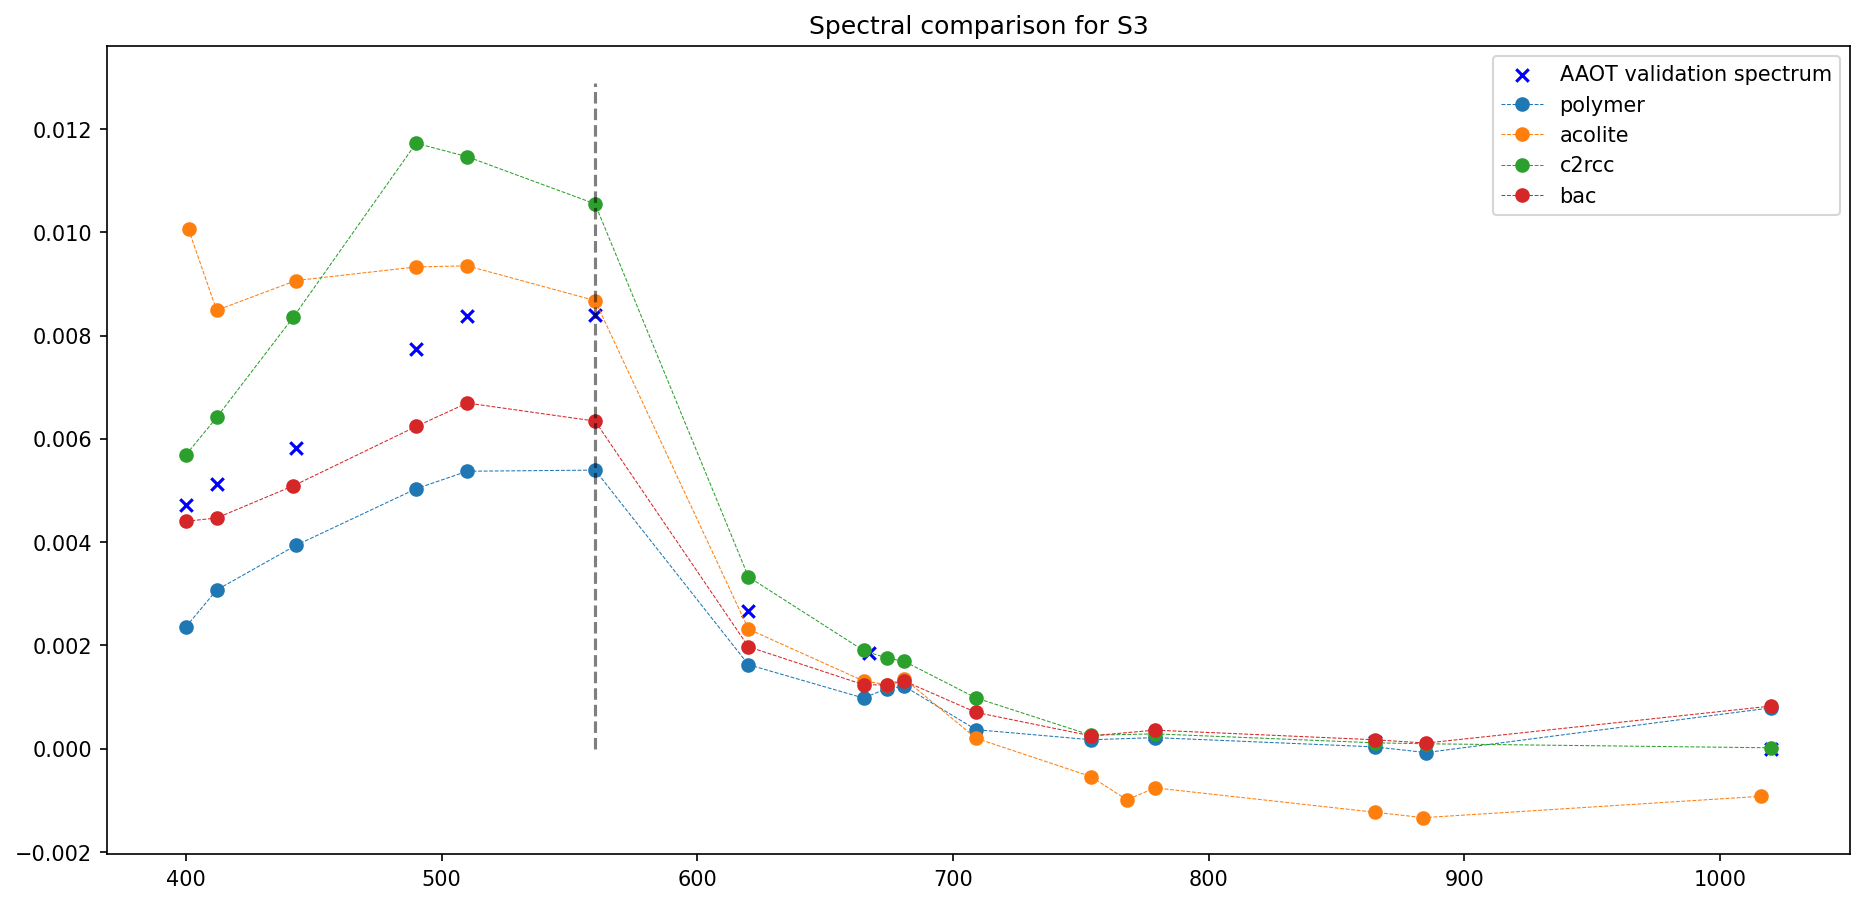

In [24]:
fig, axs = plt.subplots(1, 1, figsize=(15, 7), dpi=150)
handles = []
labels = []
maxval = 0.0
if use_validation_data:
    p1 = plt.scatter(Rrs_lambda, Rrs_vals, c="b", marker="x")
    maxval = max(maxval, max(Rrs_vals))
    handles.append(p1)
    labels.append("AAOT validation spectrum")
for opts in all_opts[sensor]:
    p1, = plt.plot(bandsets[opts["ac"]]["wavelengths"], Rrs[opts["ac"]]["Rrs"], marker="o", linestyle="--", linewidth=0.5)
    maxval = max(maxval, max(Rrs[opts["ac"]]["Rrs"]))
    handles.append(p1)
    labels.append(opts["ac"])
plt.plot([target_band[sensor], target_band[sensor]], [0, maxval*1.1], "k--", alpha=0.5)
plt.legend(handles, labels)
plt.title(f"Spectral comparison for {sensor}");

The shapes of the resulting spectra give a clear indication of where our approaches deviate from expectations. In particular, we can see that performance across the board varies greatly by wavelength, and particularly in the blue. As band ratio algorithms are often used to derive concentrations of biogeochemical variables, it is clear that these methods will give very different results depending on the approach taken.

<div class="alert alert-info" role="alert">

## Final thoughts

</div>

There are a number of important points to remember about this quick analysis. Firstly, we should point out that nearly all of these AC approaches have a variety of parameters that can be configured to make them more suitable to a given region or circumstance or to include auxiliary data that makes them more dynamically suitable to broad scale use. We have adopted none of these customisations, choosing to run each approach with only the barest default configuration. Consequently, there may be various steps that you can take to improve the performance on each of these AC methods for you chosen application and region of interest!

Secondly, a disclaimer. One comparison does not a comprehensive validation study make! We have compared a single spectra against a single product, and have made some broad observations about behaviour. We cannot, and do not, make any claim of performance of general performance of these approaches or advise as to their suitability for this region (excepting those methods that are not designed for use over water).

There are many things left to consider when performing a full validation. Have all physical factors, for example BRDF, been taken into account? What are the temporal tolerances between our insitu and remotely sensed data? What about consideration of uncertainties? All of these aspects will be considered in much more detail on day 5 of the course.

<div class="alert alert-success" role="alert">

## What next?

This notebook should give you some insights into the differing approaches and performances of various atmospheric correct approaches. While you can run with the default settings, there are a lot of other options to explore. For instance, you can adapt the approaches under consideration, try different sensors, different bands, and adapt the flags used. Once you feel ready, you can adapt this notebook to run on the data for your own ROI - we have supplied similar data for each case in the relevant ROI folder. If AERONET-OC validation data exists in your ROI, you can also adapt the notebook to include it, or simply select your own point to perform a spectral intercomparison just using the Earth observation data.

</div>

<hr>
<a href="../Index.ipynb">Index</a> | <a href="./Access_OLCI_EUMETSAT_Data_Store.ipynb">Accessing Sentinel-3 OLCI data through the EUMETSAT Data Store</a> | <a href="./Access_PACE_EarthData.ipynb">Accessing PACE OCI through EarthData</a> | <a href="./Access_MSI_CDSE.ipynb">Accessing Sentinel-2 MSI data via the CDSE</a> 
<hr>
<a href="https://gitlab.com/eo_training/msoc" target="_blank">View on GitLab</a> | <a href="https://training.eumetsat.int/" target="_blank">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int target="_blank">Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int target="_blank">Contact our training team to collaborate on and reuse this material</a></span></p>